In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from darts import TimeSeries

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/electricity_load.csv")

df.head()

,datetime,demand_kWh
0,01/01/2022 01:00,5.87
1,01/01/2022 02:00,5.95
2,01/01/2022 03:00,5.69
3,01/01/2022 04:00,6.05
4,01/01/2022 05:00,5.64


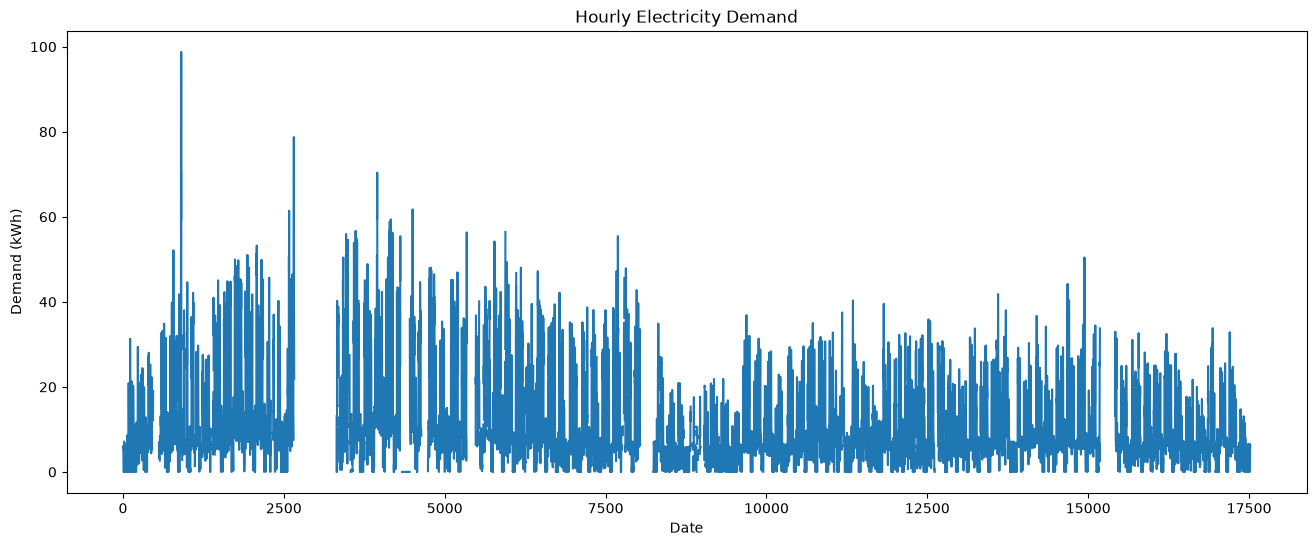

In [3]:
#plot the time series
#Plot the complete time series
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["demand_kWh"]
)

plt.title("Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")

plt.show()

In [4]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%d/%m/%Y %H:%M"
)

df = df.sort_values("datetime")

df = df.set_index("datetime")

df.head()

,demand_kWh
datetime,
2022-01-01 01:00:00,5.87
2022-01-01 02:00:00,5.95
2022-01-01 03:00:00,5.69
2022-01-01 04:00:00,6.05
2022-01-01 05:00:00,5.64


In [5]:
df["demand_kWh"] = df["demand_kWh"].interpolate(
    method="time"
)
df["demand_kWh"] = df["demand_kWh"].bfill()
df["demand_kWh"] = df["demand_kWh"].ffill()
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
demand_kWh    0
dtype: int64


In [6]:
ts = df["demand_kWh"].copy()

# Make sure timestamps are sorted
ts = ts.sort_index()
# Set hourly frequency
ts = ts.asfreq("h")

# Convert to numeric
ts = pd.to_numeric(ts, errors="coerce")

# Replace missing values
ts = ts.interpolate(method="time")
ts = ts.ffill()
ts = ts.bfill()

print(ts.head())
print()
print("Number of observations:", len(ts))
print("Missing values:", ts.isna().sum())
print("Frequency:", pd.infer_freq(ts.index))

datetime
2022-01-01 01:00:00    5.87
2022-01-01 02:00:00    5.95
2022-01-01 03:00:00    5.69
2022-01-01 04:00:00    6.05
2022-01-01 05:00:00    5.64
Freq: h, Name: demand_kWh, dtype: float64

Number of observations: 17519
Missing values: 0
Frequency: h


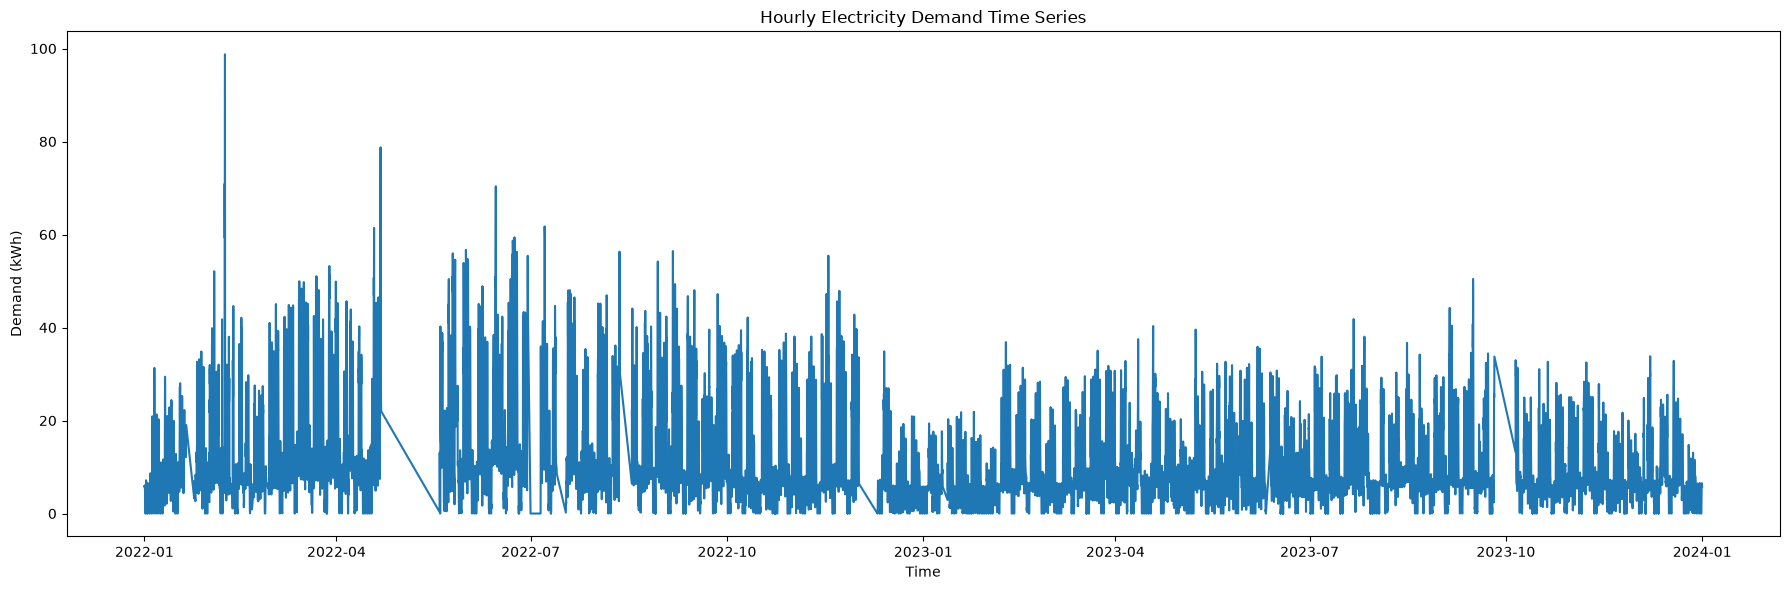

In [7]:
plt.figure(figsize=(18, 6))

plt.plot(ts)

plt.title("Hourly Electricity Demand Time Series")
plt.xlabel("Time")
plt.ylabel("Demand (kWh)")

plt.tight_layout()
plt.show()

In [8]:
#train test split
train_size = int(len(ts) * 0.80)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 14015
Testing observations : 3504

Training period:
2022-01-01 01:00:00 to 2023-08-07 23:00:00

Testing period:
2023-08-08 00:00:00 to 2023-12-31 23:00:00


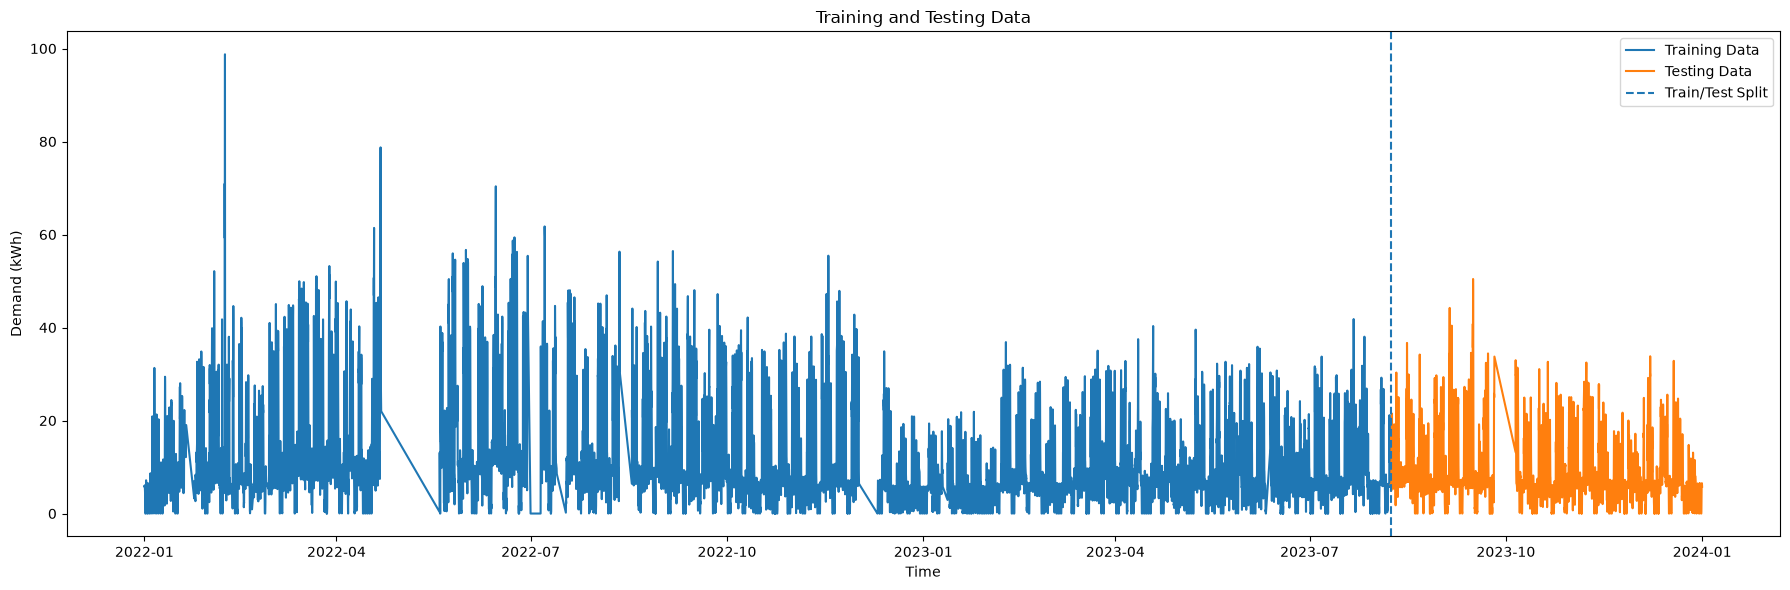

In [9]:
plt.figure(figsize=(18, 6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Testing Data")

plt.axvline(
    test.index[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Training and Testing Data")
plt.xlabel("Time")
plt.ylabel("Demand (kWh)")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#Create the common results container, Every model will add its results here.
all_results = []

all_models = {}

In [11]:
#Create one reusable evaluation function, This will calculate the metrics for AR, MA, ARMA and SARIMA.
def evaluate_forecast(
    model_name,
    model_result,
    test,
    forecast,
    results_list
):
    """
    Evaluate forecast performance.
    """

    # Convert forecast to Series
    forecast = pd.Series(forecast).copy()

    # Make sure forecast uses the test index
    if len(forecast) == len(test):
        forecast.index = test.index

    # Combine actual and forecast
    comparison = pd.DataFrame({
        "Actual": test,
        "Forecast": forecast
    }).dropna()

    # Forecast errors
    errors = (
        comparison["Actual"]
        - comparison["Forecast"]
    )

    # MAE
    mae = mean_absolute_error(
        comparison["Actual"],
        comparison["Forecast"]
    )

    # MSE
    mse = mean_squared_error(
        comparison["Actual"],
        comparison["Forecast"]
    )

    # RMSE
    rmse = np.sqrt(mse)

    # R²
    r2 = r2_score(
        comparison["Actual"],
        comparison["Forecast"]
    )

    # MAPE
    nonzero = comparison["Actual"] != 0

    if nonzero.sum() > 0:
        mape = np.mean(
            np.abs(
                errors[nonzero]
                / comparison.loc[nonzero, "Actual"]
            )
        ) * 100
    else:
        mape = np.nan

    # Store results
    results_list.append({
        "Model": model_name,
        "AIC": model_result.aic,
        "BIC": model_result.bic,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    })

    # Print results
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"AIC       : {model_result.aic:.4f}")
    print(f"BIC       : {model_result.bic:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"MSE       : {mse:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAPE (%)  : {mape:.4f}")
    print(f"R²        : {r2:.4f}")

    return comparison, errors

In [12]:
def plot_forecast(
    model_name,
    train,
    comparison,
    forecast_ci=None,
    history_hours=24 * 14,
    forecast_hours=24 * 14
):
    """
    Plot training history, actual values and forecasts.
    """

    # Limit the test period shown
    comparison_plot = comparison.iloc[:forecast_hours]

    plt.figure(figsize=(18, 7))

    # Historical data
    plt.plot(
        train.tail(history_hours),
        label="Training Data"
    )

    # Actual test data
    plt.plot(
        comparison_plot["Actual"],
        label="Actual"
    )

    # Forecast
    plt.plot(
        comparison_plot["Forecast"],
        label=f"{model_name} Forecast"
    )

    # Confidence interval
    if forecast_ci is not None:

        forecast_ci = forecast_ci.copy()

        if len(forecast_ci) == len(comparison):
            forecast_ci.index = comparison.index

        forecast_ci_plot = forecast_ci.loc[
            forecast_ci.index.intersection(
                comparison_plot.index
            )
        ]

        if len(forecast_ci_plot) > 0:

            plt.fill_between(
                forecast_ci_plot.index,
                forecast_ci_plot.iloc[:, 0],
                forecast_ci_plot.iloc[:, 1],
                alpha=0.2,
                label="95% Confidence Interval"
            )

    # Forecast start
    plt.axvline(
        comparison_plot.index[0],
        linestyle="--",
        label="Forecast Start"
    )

    plt.title(
        f"{model_name}: Actual vs Forecast"
    )

    plt.xlabel("Time")
    plt.ylabel("Demand (kWh)")

    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
def fit_and_evaluate_model(
    model_name,
    train,
    test,
    order,
    seasonal_order=(0, 0, 0, 0),
    results_list=None,
    model_store=None
):
    """
    Fit AR, MA, ARMA or SARIMA model,
    forecast the test period and evaluate performance.
    """

    print("\nFitting:", model_name)

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # Forecast entire test period
    forecast_result = result.get_forecast(
        steps=len(test)
    )

    forecast = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()

    # Evaluate
    comparison, errors = evaluate_forecast(
        model_name=model_name,
        model_result=result,
        test=test,
        forecast=forecast,
        results_list=results_list
    )

    # Store model information
    if model_store is not None:

        model_store[model_name] = {
            "result": result,
            "forecast": comparison["Forecast"],
            "comparison": comparison,
            "errors": errors,
            "forecast_ci": forecast_ci,
            "order": order,
            "seasonal_order": seasonal_order
        }

    return result, comparison, errors, forecast_ci

### AR Model

In [14]:
ar_candidates = [1, 2, 3, 4, 5]
for p in ar_candidates:

    model_name = f"AR({p})"

    fit_and_evaluate_model(
        model_name=model_name,
        train=train,
        test=test,
        order=(p, 0, 0),
        seasonal_order=(0, 0, 0, 0),
        results_list=all_results,
        model_store=all_models
    )


Fitting: AR(1)

AR(1)
AIC       : 79354.7349
BIC       : 79369.8305
MAE       : 9.6399
MSE       : 151.0594
RMSE      : 12.2906
MAPE (%)  : 99.4411
R²        : -1.6047

Fitting: AR(2)

AR(2)
AIC       : 78540.8126
BIC       : 78563.4558
MAE       : 9.6566
MSE       : 151.3483
RMSE      : 12.3024
MAPE (%)  : 99.6541
R²        : -1.6097

Fitting: AR(3)

AR(3)
AIC       : 78491.1990
BIC       : 78521.3897
MAE       : 9.6531
MSE       : 151.2875
RMSE      : 12.2999
MAPE (%)  : 99.6092
R²        : -1.6086

Fitting: AR(4)

AR(4)
AIC       : 78487.4260
BIC       : 78525.1640
MAE       : 9.6524
MSE       : 151.2762
RMSE      : 12.2994
MAPE (%)  : 99.6007
R²        : -1.6084

Fitting: AR(5)

AR(5)
AIC       : 78484.2939
BIC       : 78529.5791
MAE       : 9.6529
MSE       : 151.2844
RMSE      : 12.2998
MAPE (%)  : 99.6069
R²        : -1.6086


In [15]:
results_df = pd.DataFrame(all_results)

ar_results = results_df[
    results_df["Model"].str.startswith("AR(")
].copy()

ar_results = ar_results.sort_values(
    "RMSE"
).reset_index(drop=True)

print(ar_results)

   Model           AIC           BIC       MAE         MSE       RMSE  \
0  AR(1)  79354.734873  79369.830497  9.639905  151.059388  12.290622   
1  AR(4)  78487.425992  78525.163982  9.652385  151.276184  12.299438   
2  AR(5)  78484.293911  78529.579071  9.652870  151.284380  12.299772   
3  AR(3)  78491.199015  78521.389692  9.653052  151.287463  12.299897   
4  AR(2)  78540.812618  78563.455840  9.656573  151.348309  12.302370   

    MAPE (%)        R2  
0  99.441147 -1.604692  
1  99.600677 -1.608430  
2  99.606889 -1.608572  
3  99.609230 -1.608625  
4  99.654070 -1.609674  


### AIC and BIC are model selection criteria used to compare statistical models such as AR, MA, ARMA, ARIMA, and SARIMA.

They answer:

Which model gives a good fit without being unnecessarily complex?

In [16]:
#find the best AR model
best_ar = ar_results.iloc[0]

print("Best AR Model")
print(best_ar)

Best AR Model
Model              AR(1)
AIC         79354.734873
BIC         79369.830497
MAE             9.639905
MSE           151.059388
RMSE           12.290622
MAPE (%)       99.441147
R2             -1.604692
Name: 0, dtype: object


### MA Model

In [17]:
ma_candidates = [1, 2, 3, 4, 5]
for q in ma_candidates:

    model_name = f"MA({q})"

    fit_and_evaluate_model(
        model_name=model_name,
        train=train,
        test=test,
        order=(0, 0, q),
        seasonal_order=(0, 0, 0, 0),
        results_list=all_results,
        model_store=all_models
    )


Fitting: MA(1)

MA(1)
AIC       : 99643.3960
BIC       : 99658.4915
MAE       : 9.6808
MSE       : 151.7235
RMSE      : 12.3176
MAPE (%)  : 99.9838
R²        : -1.6161

Fitting: MA(2)

MA(2)
AIC       : 91036.6226
BIC       : 91059.2656
MAE       : 9.6811
MSE       : 151.7260
RMSE      : 12.3177
MAPE (%)  : 99.9885
R²        : -1.6162

Fitting: MA(3)

MA(3)
AIC       : 86413.1721
BIC       : 86443.3625
MAE       : 9.6789
MSE       : 151.7093
RMSE      : 12.3170
MAPE (%)  : 99.9526
R²        : -1.6159

Fitting: MA(4)

MA(4)
AIC       : 83829.9468
BIC       : 83867.6844
MAE       : 9.6790
MSE       : 151.7054
RMSE      : 12.3169
MAPE (%)  : 99.9531
R²        : -1.6158

Fitting: MA(5)

MA(5)
AIC       : 82110.0334
BIC       : 82155.3181
MAE       : 9.6790
MSE       : 151.7061
RMSE      : 12.3169
MAPE (%)  : 99.9544
R²        : -1.6158


In [18]:
# compare MA models
results_df = pd.DataFrame(all_results)

ma_results = results_df[
    results_df["Model"].str.startswith("MA(")
].copy()

ma_results = ma_results.sort_values(
    "RMSE"
).reset_index(drop=True)

print(ma_results)

   Model           AIC           BIC       MAE         MSE       RMSE  \
0  MA(4)  83829.946784  83867.684417  9.678962  151.705388  12.316874   
1  MA(5)  82110.033393  82155.318124  9.679046  151.706135  12.316904   
2  MA(3)  86413.172144  86443.362536  9.678937  151.709314  12.317034   
3  MA(1)  99643.396021  99658.491502  9.680827  151.723541  12.317611   
4  MA(2)  91036.622577  91059.265585  9.681110  151.725970  12.317710   

    MAPE (%)        R2  
0  99.953055 -1.615831  
1  99.954368 -1.615844  
2  99.952580 -1.615899  
3  99.983806 -1.616144  
4  99.988503 -1.616186  


In [19]:
best_ma = ma_results.iloc[0]

print("Best MA Model")
print(best_ma)

Best MA Model
Model              MA(4)
AIC         83829.946784
BIC         83867.684417
MAE             9.678962
MSE           151.705388
RMSE           12.316874
MAPE (%)       99.953055
R2             -1.615831
Name: 0, dtype: object


## ARMA model

In [20]:
arma_candidates = [
    (1, 1),
    (1, 2),
    (2, 1),
    (2, 2),
    (2, 3),
    (3, 1),
    (3, 2)
]

In [21]:
for p, q in arma_candidates:

    model_name = f"ARMA({p},{q})"

    fit_and_evaluate_model(
        model_name=model_name,
        train=train,
        test=test,
        order=(p, 0, q),
        seasonal_order=(0, 0, 0, 0),
        results_list=all_results,
        model_store=all_models
    )


Fitting: ARMA(1,1)

ARMA(1,1)
AIC       : 78501.4493
BIC       : 78524.0925
MAE       : 9.6534
MSE       : 151.2940
RMSE      : 12.3002
MAPE (%)  : 99.6143
R²        : -1.6087

Fitting: ARMA(1,2)

ARMA(1,2)
AIC       : 78496.0377
BIC       : 78526.2284
MAE       : 9.6543
MSE       : 151.3089
RMSE      : 12.3008
MAPE (%)  : 99.6252
R²        : -1.6090

Fitting: ARMA(2,1)

ARMA(2,1)
AIC       : 78500.9986
BIC       : 78531.1896
MAE       : 9.6542
MSE       : 151.3077
RMSE      : 12.3007
MAPE (%)  : 99.6243
R²        : -1.6090

Fitting: ARMA(2,2)

ARMA(2,2)
AIC       : 78497.1654
BIC       : 78534.9038
MAE       : 9.6542
MSE       : 151.3076
RMSE      : 12.3007
MAPE (%)  : 99.6243
R²        : -1.6090

Fitting: ARMA(2,3)


/home/karma/ist409/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(



ARMA(2,3)
AIC       : 77860.9662
BIC       : 77906.2518
MAE       : 5.0334
MSE       : 61.2065
RMSE      : 7.8235
MAPE (%)  : 304.1826
R²        : -0.0554

Fitting: ARMA(3,1)

ARMA(3,1)
AIC       : 78492.3739
BIC       : 78530.1122
MAE       : 9.6525
MSE       : 151.2786
RMSE      : 12.2995
MAPE (%)  : 99.6025
R²        : -1.6085

Fitting: ARMA(3,2)

ARMA(3,2)
AIC       : 78493.3560
BIC       : 78538.6420
MAE       : 9.6523
MSE       : 151.2756
RMSE      : 12.2994
MAPE (%)  : 99.6002
R²        : -1.6084


In [22]:
results_df = pd.DataFrame(all_results)

arma_results = results_df[
    results_df["Model"].str.startswith("ARMA(")
].copy()

arma_results = arma_results.sort_values(
    "RMSE"
).reset_index(drop=True)

print(arma_results)

       Model           AIC           BIC       MAE         MSE       RMSE  \
0  ARMA(2,3)  77860.966167  77906.251755  5.033416   61.206456   7.823456   
1  ARMA(3,2)  78493.355977  78538.641993  9.652348  151.275585  12.299414   
2  ARMA(3,1)  78492.373892  78530.112239  9.652529  151.278608  12.299537   
3  ARMA(1,1)  78501.449255  78524.092477  9.653446  151.293986  12.300162   
4  ARMA(2,2)  78497.165422  78534.903769  9.654232  151.307624  12.300716   
5  ARMA(2,1)  78500.998625  78531.189588  9.654234  151.307673  12.300718   
6  ARMA(1,2)  78496.037723  78526.228401  9.654303  151.308877  12.300767   

     MAPE (%)        R2  
0  304.182569 -0.055373  
1   99.600200 -1.608420  
2   99.602517 -1.608472  
3   99.614299 -1.608737  
4   99.624308 -1.608972  
5   99.624336 -1.608973  
6   99.625209 -1.608994  


In [23]:
#find best arma model
best_arma = arma_results.iloc[0]
print("Best ARMA Model")
print(best_arma)

Best ARMA Model
Model          ARMA(2,3)
AIC         77860.966167
BIC         77906.251755
MAE             5.033416
MSE            61.206456
RMSE            7.823456
MAPE (%)      304.182569
R2             -0.055373
Name: 0, dtype: object


# SARIMA
SARIMA is usually written as:

$$ \boxed{SARIMA(p,d,q)(P,D,Q)_s} $$

It has six orders/parameters, plus the seasonal period \(s\).
| Parameter | Meaning                        | Typical values |
| --------- | ------------------------------ | -------------- |
| **p**     | AR (autoregressive) order      | 0, 1, 2, ...   |
| **d**     | Number of ordinary differences | 0, 1, 2        |
| **q**     | MA (moving-average) order      | 0, 1, 2, ...   |

For example:

SARIMA(1,1,1)(1,1,1)₍₂₄₎

means:

p = 1: one non-seasonal AR term
d = 1: first-order differencing
q = 1: one non-seasonal MA term
P = 1: one seasonal AR term
D = 1: seasonal differencing
Q = 1: one seasonal MA term
s = 24: seasonality repeats every 24 observations
For Hourly Electricity Data

If you have hourly electricity load, then:

s = 24

is a natural choice for daily seasonality.

Therefore, a reasonable starting model would be:

SARIMA(1,1,1)(1,1,1)₍₂₄₎
	​


In [24]:
sarima_candidates = [

    {
        "name": "SARIMA(2,0,0)(1,0,0)[24]",
        "order": (2, 0, 0),
        "seasonal_order": (1, 0, 0, 24)
    },

    {
        "name": "SARIMA(2,0,0)(0,0,1)[24]",
        "order": (2, 0, 0),
        "seasonal_order": (0, 0, 1, 24)
    }

]

In [25]:
for config in sarima_candidates:

    try:

        fit_and_evaluate_model(
            model_name=config["name"],
            train=train,
            test=test,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            results_list=all_results,
            model_store=all_models
        )

    except Exception as e:

        print(
            f"\nFailed to fit {config['name']}"
        )

        print("Error:", e)


Fitting: SARIMA(2,0,0)(1,0,0)[24]

SARIMA(2,0,0)(1,0,0)[24]
AIC       : 76464.8494
BIC       : 76495.0336
MAE       : 9.6187
MSE       : 150.5944
RMSE      : 12.2717
MAPE (%)  : 99.2693
R²        : -1.5967

Fitting: SARIMA(2,0,0)(0,0,1)[24]

SARIMA(2,0,0)(0,0,1)[24]
AIC       : 76941.1291
BIC       : 76971.3135
MAE       : 9.6405
MSE       : 151.0375
RMSE      : 12.2897
MAPE (%)  : 99.5030
R²        : -1.6043


In [26]:
results_df = pd.DataFrame(all_results)

sarima_results = results_df[
    results_df["Model"].str.startswith("SARIMA")
].copy()

sarima_results = sarima_results.sort_values(
    "RMSE"
).reset_index(drop=True)

print(sarima_results)

                      Model           AIC           BIC       MAE         MSE  \
0  SARIMA(2,0,0)(1,0,0)[24]  76464.849446  76495.033553  9.618686  150.594381   
1  SARIMA(2,0,0)(0,0,1)[24]  76941.129058  76971.313450  9.640457  151.037550   

        RMSE   MAPE (%)        R2  
0  12.271690  99.269279 -1.596674  
1  12.289734  99.503045 -1.604316  


In [27]:
best_sarima = sarima_results.iloc[0]

print("Best SARIMA Model")
print("=" * 60)
print(best_sarima)

Best SARIMA Model
Model       SARIMA(2,0,0)(1,0,0)[24]
AIC                     76464.849446
BIC                     76495.033553
MAE                         9.618686
MSE                       150.594381
RMSE                        12.27169
MAPE (%)                   99.269279
R2                         -1.596674
Name: 0, dtype: object


### Comparing all of the models

In [28]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

results_df

,Rank,Model,AIC,BIC,MAE,MSE,RMSE,MAPE (%),R2
0,1,"ARMA(2,3)",77860.966167,77906.251755,5.033416,61.206456,7.823456,304.182569,-0.055373
1,2,"SARIMA(2,0,0)(1,0,0)[24]",76464.849446,76495.033553,9.618686,150.594381,12.271690,99.269279,-1.596674
2,3,"SARIMA(2,0,0)(0,0,1)[24]",76941.129058,76971.313450,9.640457,151.037550,12.289734,99.503045,-1.604316
3,4,AR(1),79354.734873,79369.830497,9.639905,151.059388,12.290622,99.441147,-1.604692
4,5,"ARMA(3,2)",78493.355977,78538.641993,9.652348,151.275585,12.299414,99.600200,-1.608420
5,6,AR(4),78487.425992,78525.163982,9.652385,151.276184,12.299438,99.600677,-1.608430
6,7,"ARMA(3,1)",78492.373892,78530.112239,9.652529,151.278608,12.299537,99.602517,-1.608472
7,8,AR(5),78484.293911,78529.579071,9.652870,151.284380,12.299772,99.606889,-1.608572
8,9,AR(3),78491.199015,78521.389692,9.653052,151.287463,12.299897,99.609230,-1.608625
9,10,"ARMA(1,1)",78501.449255,78524.092477,9.653446,151.293986,12.300162,99.614299,-1.608737


In [29]:
# best overall model
best_model = results_df.iloc[0]

print("=" * 70)
print("BEST MODEL BASED ON TEST RMSE")
print("=" * 70)

print(f"Model     : {best_model['Model']}")
print(f"MAE       : {best_model['MAE']:.4f}")
print(f"RMSE      : {best_model['RMSE']:.4f}")
print(f"MAPE (%)  : {best_model['MAPE (%)']:.4f}")
print(f"R²        : {best_model['R2']:.4f}")
print(f"AIC       : {best_model['AIC']:.4f}")
print(f"BIC       : {best_model['BIC']:.4f}")

BEST MODEL BASED ON TEST RMSE
Model     : ARMA(2,3)
MAE       : 5.0334
RMSE      : 7.8235
MAPE (%)  : 304.1826
R²        : -0.0554
AIC       : 77860.9662
BIC       : 77906.2518


In [30]:
#best model AIC
best_aic_model = results_df.loc[
    results_df["AIC"].idxmin()
]

print("Best Model Based on AIC:")
print(best_aic_model["Model"])

Best Model Based on AIC:
SARIMA(2,0,0)(1,0,0)[24]


In [31]:
# best model BIC
best_bic_model = results_df.loc[
    results_df["BIC"].idxmin()
]

print("Best Model Based on BIC:")
print(best_bic_model["Model"])

Best Model Based on BIC:
SARIMA(2,0,0)(1,0,0)[24]


In [32]:
# model comparision by rmse
def plot_model_metric(
    results_df,
    metric="RMSE"
):

    results_sorted = results_df.sort_values(
        metric,
        ascending=True
    )

    plt.figure(figsize=(16, 7))

    plt.bar(
        results_sorted["Model"],
        results_sorted[metric]
    )

    plt.title(
        f"Model Comparison Based on {metric}"
    )

    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

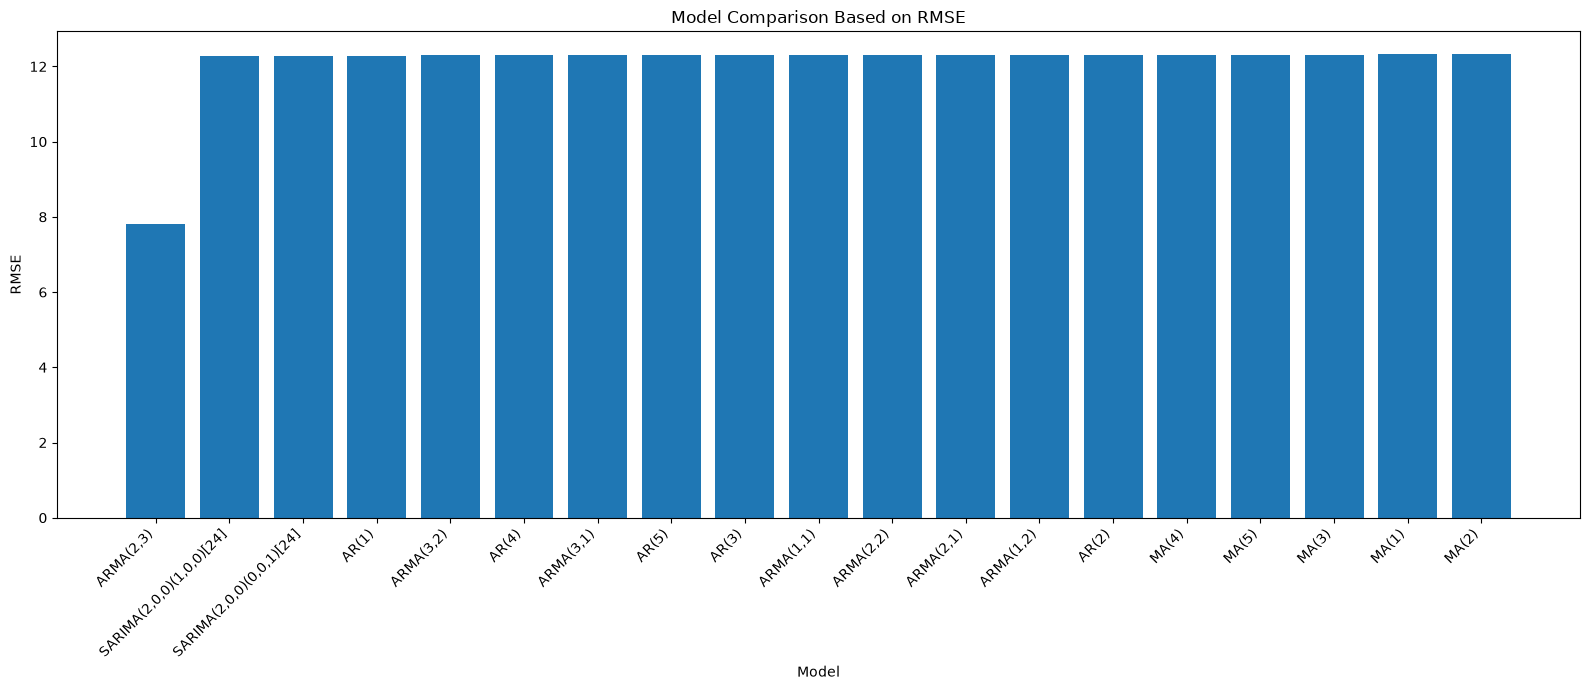

In [33]:
plot_model_metric(
    results_df,
    metric="RMSE"
)

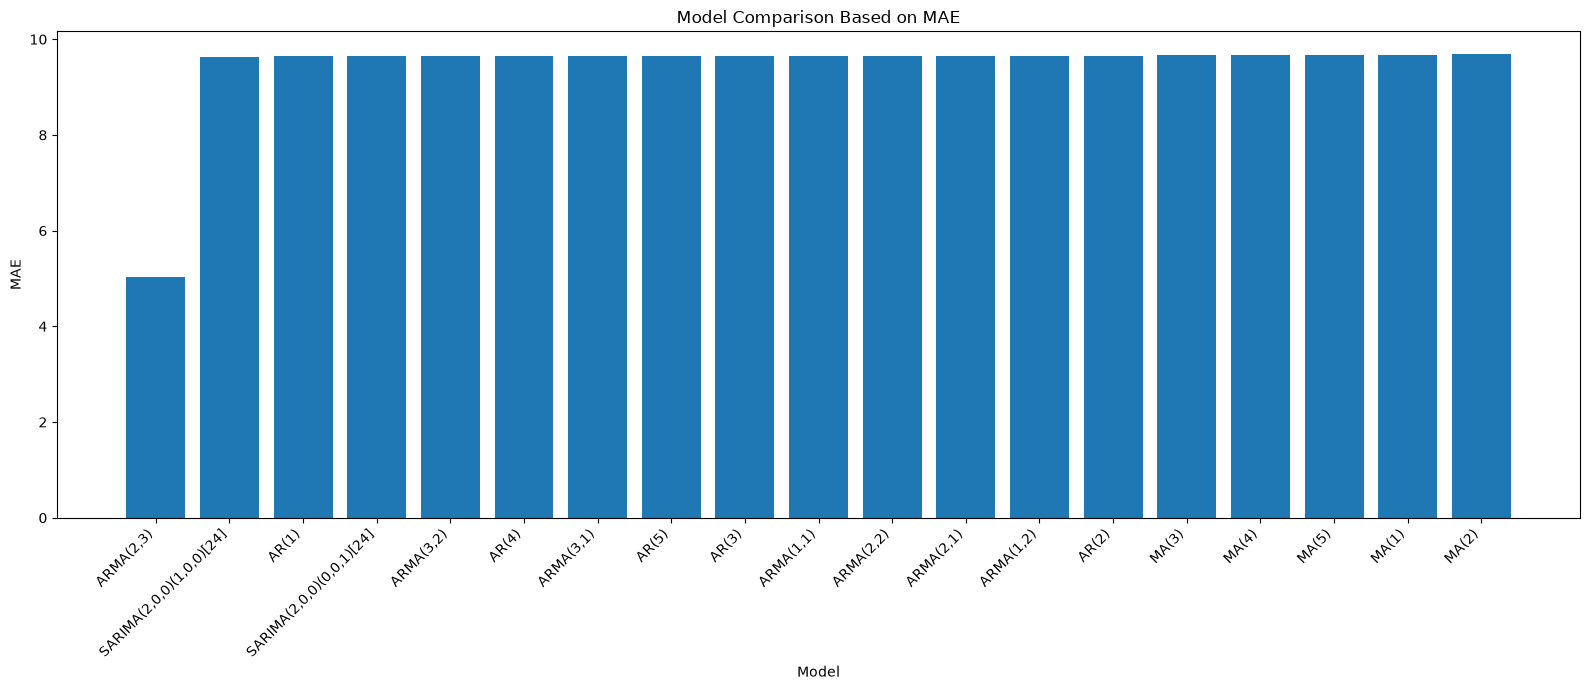

In [34]:
plot_model_metric(
    results_df,
    metric="MAE"
)

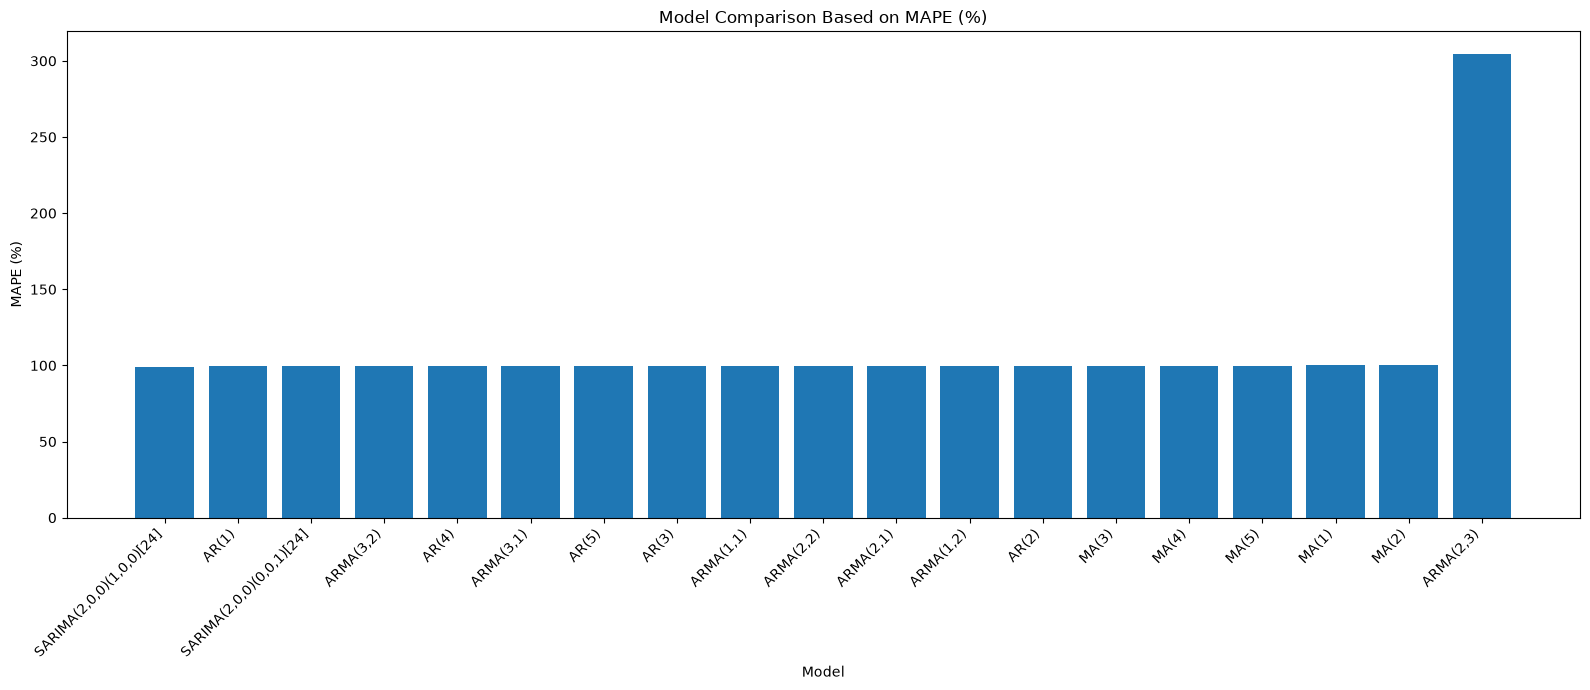

In [35]:
plot_model_metric(
    results_df,
    metric="MAPE (%)"
)

In [36]:
# plot the best model
best_model_name = results_df.iloc[0]["Model"]

print("Best model:", best_model_name)
best_model_data = all_models[best_model_name]

Best model: ARMA(2,3)


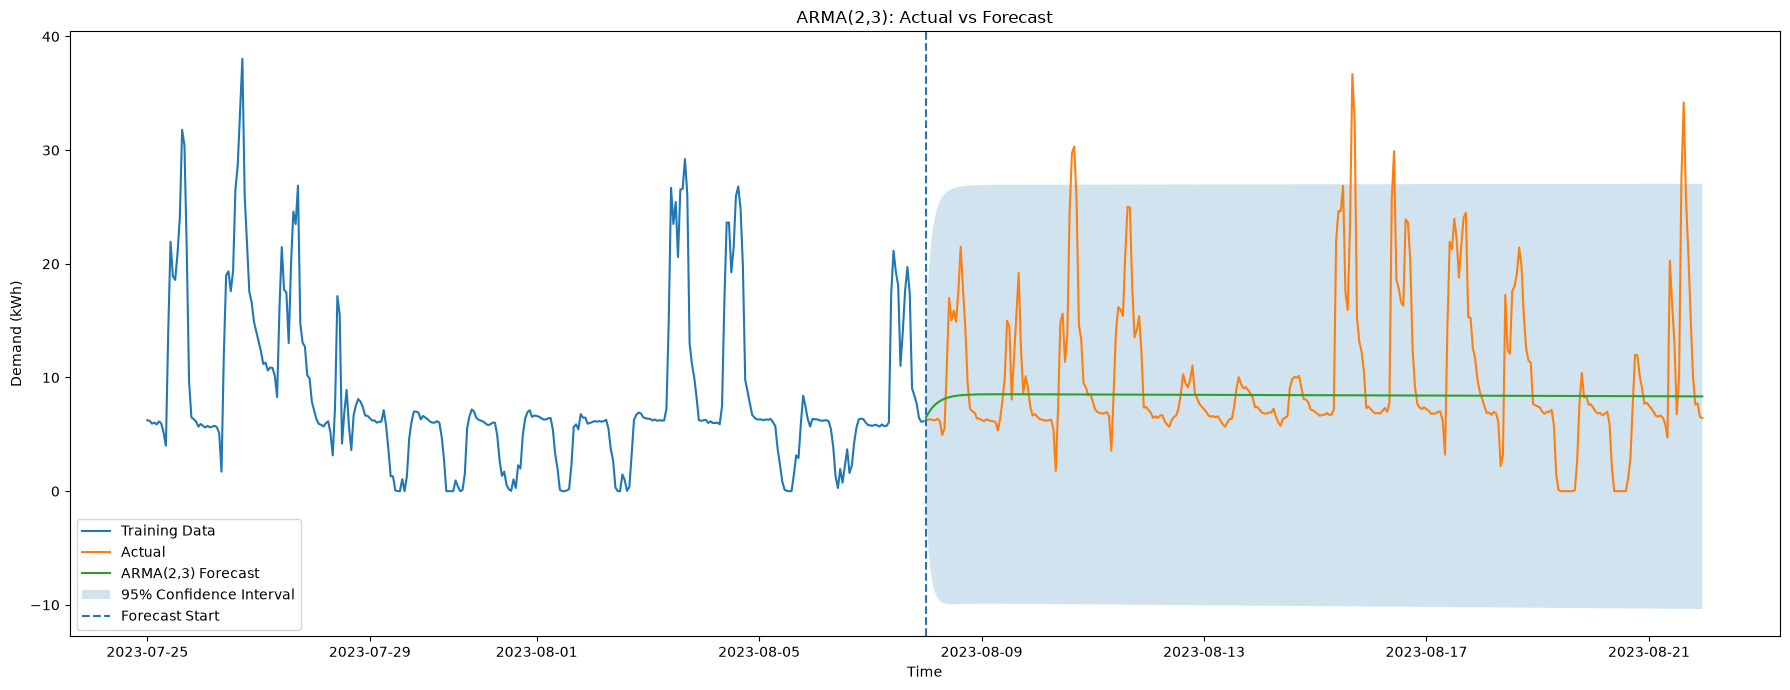

In [37]:
plot_forecast(
    model_name=best_model_name,
    train=train,
    comparison=best_model_data["comparison"],
    forecast_ci=best_model_data["forecast_ci"],
    history_hours=24 * 14,
    forecast_hours=24 * 14
)

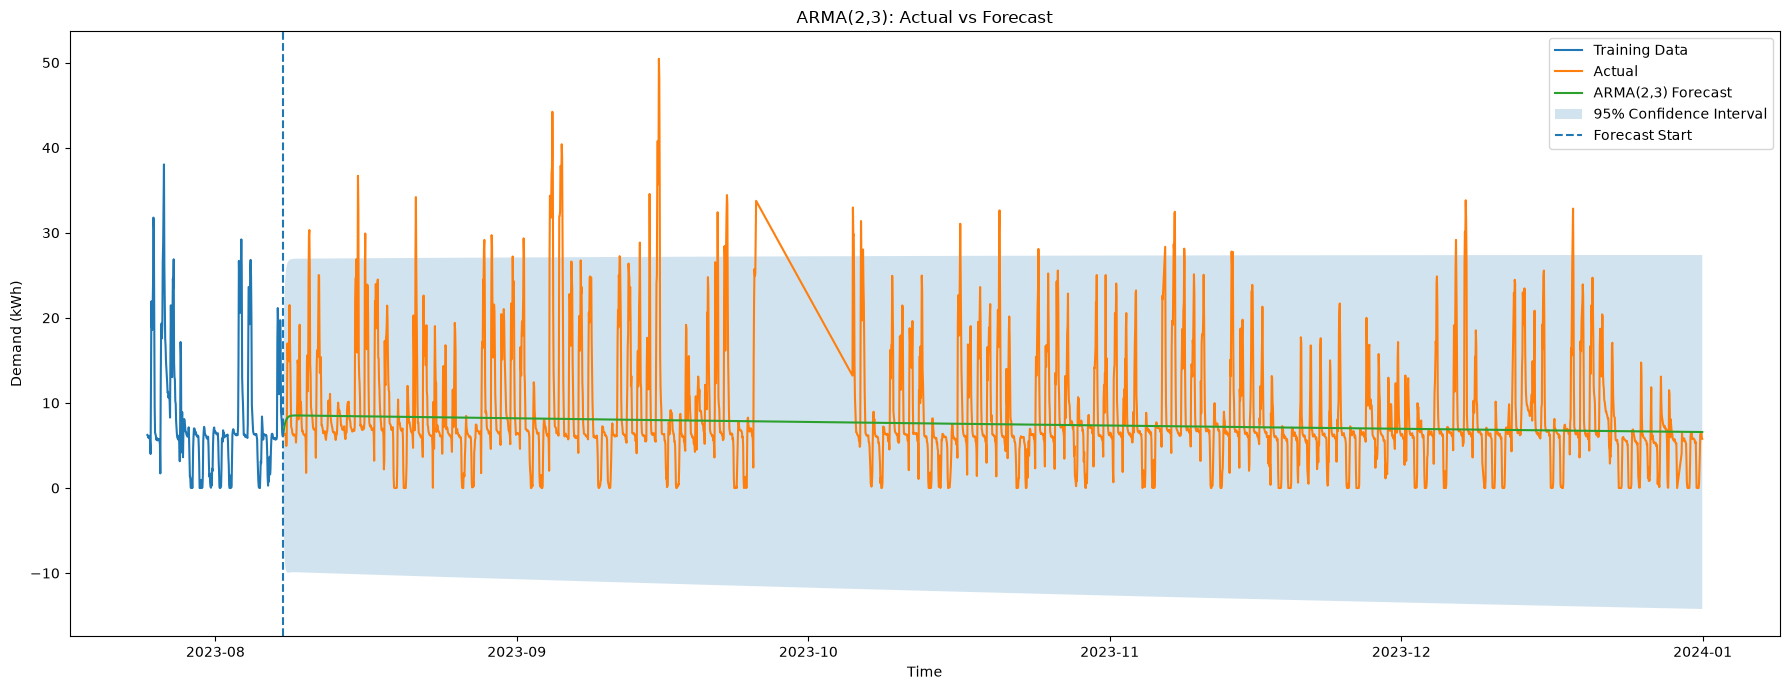

In [38]:
plot_forecast(
    model_name=best_model_name,
    train=train,
    comparison=best_model_data["comparison"],
    forecast_ci=best_model_data["forecast_ci"],
    history_hours=24 * 14,
    forecast_hours=len(test)
)

### Compare the best AR, MA, ARMA and SARIMA forecasts

In [39]:
best_ar_name = ar_results.iloc[0]["Model"]
best_ma_name = ma_results.iloc[0]["Model"]
best_arma_name = arma_results.iloc[0]["Model"]
best_sarima_name = sarima_results.iloc[0]["Model"]

print("Best AR     :", best_ar_name)
print("Best MA     :", best_ma_name)
print("Best ARMA   :", best_arma_name)
print("Best SARIMA :", best_sarima_name)

Best AR     : AR(1)
Best MA     : MA(4)
Best ARMA   : ARMA(2,3)
Best SARIMA : SARIMA(2,0,0)(1,0,0)[24]


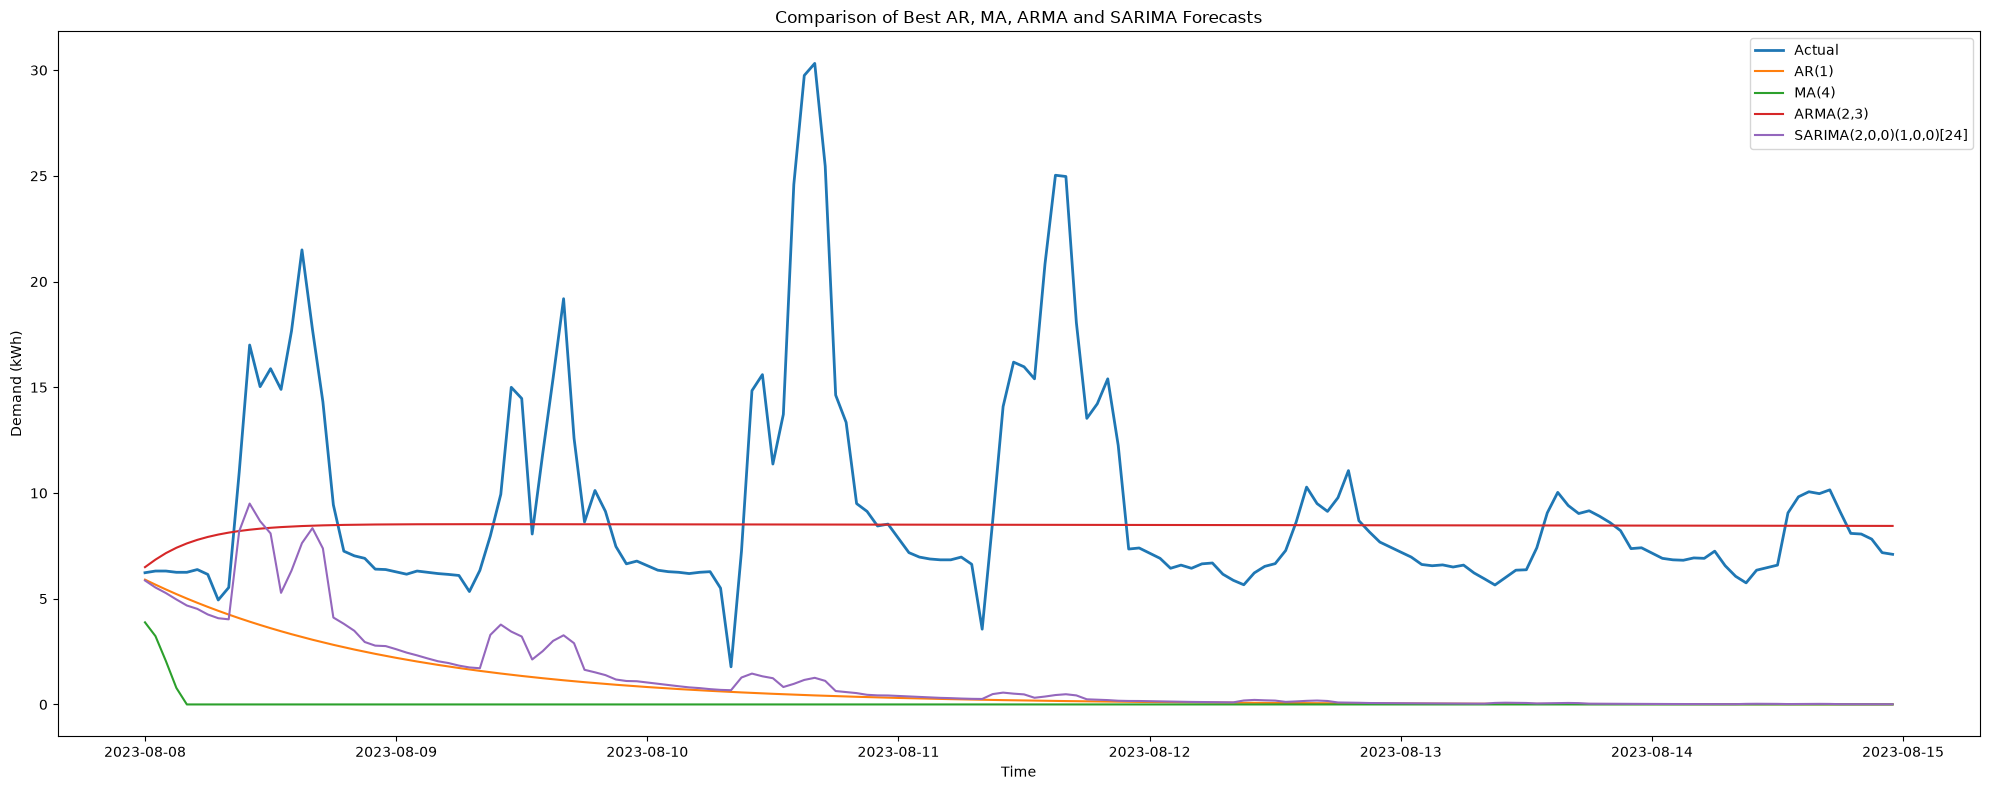

In [40]:
hours_to_plot = 24 * 7

plt.figure(figsize=(20, 8))

# Actual values
plt.plot(
    test.iloc[:hours_to_plot],
    label="Actual",
    linewidth=2
)

# Best AR
plt.plot(
    all_models[best_ar_name]["comparison"]["Forecast"].iloc[:hours_to_plot],
    label=best_ar_name
)

# Best MA
plt.plot(
    all_models[best_ma_name]["comparison"]["Forecast"].iloc[:hours_to_plot],
    label=best_ma_name
)

# Best ARMA
plt.plot(
    all_models[best_arma_name]["comparison"]["Forecast"].iloc[:hours_to_plot],
    label=best_arma_name
)

# Best SARIMA
plt.plot(
    all_models[best_sarima_name]["comparison"]["Forecast"].iloc[:hours_to_plot],
    label=best_sarima_name
)

plt.title(
    "Comparison of Best AR, MA, ARMA and SARIMA Forecasts"
)

plt.xlabel("Time")
plt.ylabel("Demand (kWh)")

plt.legend()

plt.tight_layout()
plt.show()